# Stage 1 - Strong Public Baseline A: the 61st-place pipeline
## Hull Tactical Market Prediction (PMLDL 2026)

**Notebook 2 of 5.** Re-implementation of the publicly shared 61st-place solution as a
*strong* baseline.

---
### Attribution
Source notebook (public Kaggle kernel):
<https://www.kaggle.com/code/rafanikitas/hull-eda-training-pipeline>
Accompanying public write-up: 61st-place solution thread for the Hull Tactical Market
Prediction competition.

Ideas taken from that public work, re-implemented here on top of this project's `src/`
modules (no verbatim code reuse):

| # | Idea from the public solution | Where it lives here |
|---|---|---|
| 1 | Temporal context for ~14 hand-picked columns: lags `[1,3,5,7,14,20]`, rolling mean/std over `[2,5,10,20,60]` | `src.features.add_temporal_features` |
| 2 | A **single** LightGBM regressor rather than an ensemble (their multi-model attempts scored worse) | this notebook |
| 3 | Optuna selecting hyper-parameters by **mean Spearman rank correlation** over chronological folds, while LightGBM itself optimises RMSE | `objective()` below |
| 4 | A deliberately **binary allocation** (`0` = risk-free, `1` = market exposure) as a form of regularisation | `src.allocation.binary_allocation` |

### Deviations from the public notebook (and why)
* **Imputation** - the public version fills missing values with medians of the whole file;
  here medians are fitted inside each training fold (`LeakSafeImputer`) to remove that leak.
* **Validation** - `TimeSeriesSplit` is replaced by the project-wide purged/embargoed split,
  so this baseline is comparable with every other model in the repository.
* **Hyper-parameter search** - run on a *development region* (first 60% of rows) with its own
  inner purged CV, then frozen. Searching directly on the evaluation folds would make the
  reported scores optimistic.
* **Inference server** - the Kaggle `kaggle_evaluation` serving code is out of scope for an
  offline, reproducible academic pipeline and is replaced by an offline fold evaluation.

No author names or team identifiers from the public sources are reproduced anywhere.


In [1]:
# --- reproducible environment -------------------------------------------------------
import os, sys, warnings, json
from pathlib import Path

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in {"baselines", "proposed_model", "model_improvements"} else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import SEED, TARGET, RETURN_COL, RISK_FREE_COL, set_seed
from src.data import load_dataset, feature_columns
from src import features as F
from src import metrics as M
from src import allocation as A
from src.validation import default_cv, describe_folds
from src.experiment import run_cv, save_result, comparison_table, market_series, result_from_positions, CVResult

set_seed(SEED)
QUICK = os.environ.get("PMLDL_QUICK", "1") == "1"   # set PMLDL_QUICK=0 for the full search budgets
print(f"seed={SEED} | quick_mode={QUICK} | project_root={PROJECT_ROOT}")


seed=42 | quick_mode=True | project_root=/home/claude/proj


In [2]:
df, info = load_dataset(PROJECT_ROOT / "data")
print(info.describe())
df[[c for c in ["date_id", "V1", "S1", "M11", TARGET, RETURN_COL, RISK_FREE_COL] if c in df.columns]].tail(3)


SYNTHETIC SURROGATE data (Kaggle CSV not found) | rows=5,999 | anonymised features=95
SYNTHETIC SURROGATE data (Kaggle CSV not found) | rows=5,999 | anonymised features=95


,date_id,V1,S1,M11,market_forward_excess_returns,forward_returns,risk_free_rate
5996,5996,0.149075,-0.842576,-0.018065,-0.000546,-0.000502,0.000045
5997,5997,0.145132,-0.511462,-0.014140,-0.004002,-0.003958,0.000044
5998,5998,0.176105,-0.491259,-0.023940,-0.010621,-0.010577,0.000044


In [3]:
cv = default_cv(n_splits=5, purge=1, embargo=10)   # identical in every notebook of this project
market, risk_free = market_series(df)
describe_folds(cv, df)


,fold,train_start,train_end,n_train,gap,valid_start,valid_end,n_valid
0,1,0,992,993,11,1004,2002,999
1,2,0,1991,1992,11,2003,3001,999
2,3,0,2990,2991,11,3002,4000,999
3,4,0,3989,3990,11,4001,4999,999
4,5,0,4988,4989,11,5000,5998,999


## 1. Temporal feature engineering

14 promising columns are expanded with lags and rolling statistics: 6 lags + 5 rolling
means + 5 rolling standard deviations = 16 derived columns each. The intention of the
original solution was to *preserve the breadth of the original dataset while adding deeper
history only where it appears most useful* - a feature's current level often means little
without knowing whether it is rising, stable or unusually volatile.

All of these transformations read rows `<= t` only, so computing them before splitting is
leak-free.

In [4]:
COLS_TO_DROP = ["E7", "V10", "S3", "M1", "M14"]   # dropped in the public solution

base = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])
feat_df = F.add_temporal_features(
    base,
    cols=F.TOP_FEATURES_FOR_FE,
    lags=F.LAG_PERIODS,
    windows=F.ROLLING_WINDOWS,
)

FEATURES = F.model_feature_columns(feat_df)
X = feat_df[FEATURES].copy()
y = feat_df[TARGET].copy()

used = [c for c in F.TOP_FEATURES_FOR_FE if c in base.columns]
print(f"columns expanded: {len(used)} -> {len(used) * (len(F.LAG_PERIODS) + 2 * len(F.ROLLING_WINDOWS))} new temporal features")
print(f"design matrix: {X.shape}")


columns expanded: 14 -> 224 new temporal features
design matrix: (5999, 314)


## 2. Hyper-parameter search (Optuna, rank-correlation objective)

LightGBM trains against RMSE, but the *selection* criterion is the mean Spearman rank
correlation across chronological folds: in a problem this noisy, ordering strong and weak
opportunities correctly is more attainable than predicting magnitudes.

The search runs on the development region only (first 60% of rows) with an inner purged CV
of 3 folds. Set `PMLDL_QUICK=0` to use the full budget.

In [5]:
import optuna
import lightgbm as lgb
from src.features import LeakSafeImputer
from src.validation import default_cv as _cv

optuna.logging.set_verbosity(optuna.logging.WARNING)

DEV_END = int(0.6 * len(X))
X_dev, y_dev = X.iloc[:DEV_END], y.iloc[:DEV_END]
inner_cv = _cv(n_splits=3, purge=1, embargo=10)
N_TRIALS = 12 if QUICK else 60


def objective(trial):
    params = dict(
        objective="regression",
        metric="rmse",
        n_estimators=trial.suggest_int("n_estimators", 200, 1200),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.07, log=True),
        max_depth=trial.suggest_int("max_depth", 4, 10),
        num_leaves=trial.suggest_int("num_leaves", 16, 256, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        random_state=SEED,
        verbosity=-1,
        n_jobs=-1,
    )
    scores = []
    for tr, va in inner_cv.split(X_dev):
        imp = LeakSafeImputer().fit(X_dev.iloc[tr])
        model = lgb.LGBMRegressor(**params)
        model.fit(imp.transform(X_dev.iloc[tr]), y_dev.iloc[tr])
        pred = model.predict(imp.transform(X_dev.iloc[va]))
        scores.append(M.spearman_ic(y_dev.iloc[va], pred))
    return float(np.nanmean(scores))


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

BEST_PARAMS = dict(study.best_params, random_state=SEED, verbosity=-1, n_jobs=-1, subsample_freq=1)
print(f"trials: {len(study.trials)} | best inner-CV rank IC: {study.best_value:+.4f}")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


[W 2026-09-14 16:36:42,887] Trial 3 failed with parameters: {'n_estimators': 714, 'learning_rate': 0.031670023893135654, 'max_depth': 4, 'num_leaves': 85, 'min_child_samples': 50, 'reg_lambda': 0.0018205657658407262, 'reg_alpha': 6.245139574743075, 'colsample_bytree': 0.9862528132298237, 'subsample': 0.9233589392465844} because of the following error: The value nan is not acceptable.


[W 2026-09-14 16:36:42,889] Trial 3 failed with value nan.


[W 2026-09-14 16:37:03,771] Trial 5 failed with parameters: {'n_estimators': 863, 'learning_rate': 0.018341143951012818, 'max_depth': 7, 'num_leaves': 72, 'min_child_samples': 53, 'reg_lambda': 7.556810141274429, 'reg_alpha': 1.2604664585649468, 'colsample_bytree': 0.9757995766256756, 'subsample': 0.9579309401710595} because of the following error: The value nan is not acceptable.


[W 2026-09-14 16:37:03,773] Trial 5 failed with value nan.


[W 2026-09-14 16:37:18,244] Trial 7 failed with parameters: {'n_estimators': 557, 'learning_rate': 0.017274966088532233, 'max_depth': 7, 'num_leaves': 23, 'min_child_samples': 165, 'reg_lambda': 0.0019870215385428634, 'reg_alpha': 8.862326508576253, 'colsample_bytree': 0.908897907718663, 'subsample': 0.679486272613669} because of the following error: The value nan is not acceptable.


[W 2026-09-14 16:37:18,246] Trial 7 failed with value nan.


trials: 12 | best inner-CV rank IC: +0.0366
  n_estimators: 798
  learning_rate: 0.0601276332111238
  max_depth: 4
  num_leaves: 27
  min_child_samples: 28
  reg_lambda: 0.02001342062287998
  reg_alpha: 0.03586816498627549
  colsample_bytree: 0.7085396127095583
  subsample: 0.9314950036607718


## 3. Evaluation on the shared folds

The frozen configuration is retrained on every purged fold. The headline allocation is the
binary policy of the original solution; a naive linear sizing rule is evaluated alongside
it to show *why* the authors of the public solution ended up preferring the binary one.

In [6]:
res_61 = run_cv(
    X, y, market, risk_free,
    model_factory=lambda: lgb.LGBMRegressor(**BEST_PARAMS),
    allocator=A.binary_allocation,
    name="61st-place pipeline (LGBM + binary policy)", stage="1-strong-baseline", cv=cv,
)
save_result(res_61)


  fold 1: IC=+0.0520 RMSE=0.00941 penalised Sharpe=+0.751


  fold 2: IC=-0.0559 RMSE=0.01273 penalised Sharpe=-0.400


  fold 3: IC=+0.0329 RMSE=0.01387 penalised Sharpe=+0.526


  fold 4: IC=+0.0638 RMSE=0.00996 penalised Sharpe=+0.704


  fold 5: IC=-0.0334 RMSE=0.01978 penalised Sharpe=-0.062
  >>> 61st-place pipeline (LGBM + binary policy): mean IC=+0.0119 | mean penalised Sharpe=+0.304


PosixPath('/home/claude/proj/results/61st-place_pipeline__lgbm___binary_policy_.json')

In [7]:
# same forecasts, different sizing rule: position = clip(1 + k * pred, 0, 2)
K_DEV = 100.0
res_61_naive = run_cv(
    X, y, market, risk_free,
    model_factory=lambda: lgb.LGBMRegressor(**BEST_PARAMS),
    allocator=lambda p: A.naive_linear_allocation(p, k=K_DEV),
    name="61st-place pipeline (LGBM + naive sizing)", stage="1-strong-baseline", cv=cv,
)
save_result(res_61_naive)


  fold 1: IC=+0.0520 RMSE=0.00941 penalised Sharpe=+1.397


  fold 2: IC=-0.0559 RMSE=0.01273 penalised Sharpe=-0.363


  fold 3: IC=+0.0329 RMSE=0.01387 penalised Sharpe=+0.374


  fold 4: IC=+0.0638 RMSE=0.00996 penalised Sharpe=+0.541


  fold 5: IC=-0.0334 RMSE=0.01978 penalised Sharpe=+0.362
  >>> 61st-place pipeline (LGBM + naive sizing): mean IC=+0.0119 | mean penalised Sharpe=+0.462


PosixPath('/home/claude/proj/results/61st-place_pipeline__lgbm___naive_sizing_.json')

## 4. What the model actually uses

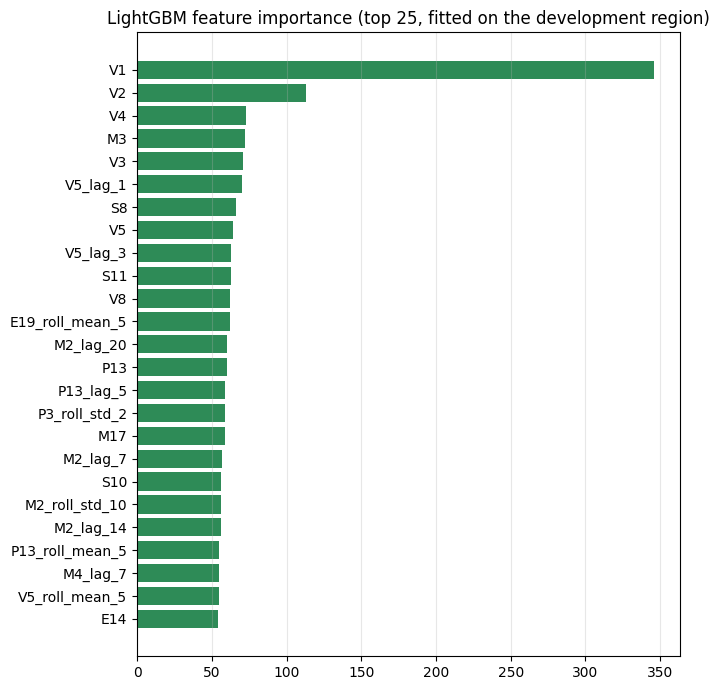

share of total importance carried by engineered temporal features: 65.2%


In [8]:
imp = LeakSafeImputer().fit(X.iloc[:DEV_END])
final_model = lgb.LGBMRegressor(**BEST_PARAMS).fit(imp.transform(X.iloc[:DEV_END]), y.iloc[:DEV_END])

gain = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top = gain.head(25)[::-1]

plt.figure(figsize=(7, 7))
plt.barh(top.index, top.to_numpy(), color="seagreen")
plt.title("LightGBM feature importance (top 25, fitted on the development region)")
plt.grid(alpha=.3, axis="x"); plt.tight_layout(); plt.show()

share = gain[[c for c in gain.index if "_lag_" in c or "_roll_" in c]].sum() / max(gain.sum(), 1e-9)
print(f"share of total importance carried by engineered temporal features: {share:.1%}")


## 5. Results so far

In [9]:
display(comparison_table())

fold_df = pd.DataFrame(res_61.fold_metrics)[["fold", "spearman_ic", "rmse", "penalised_sharpe", "vol_ratio_vs_market"]]
display(fold_df.round(4))


,,spearman_ic,rmse,r2,sharpe,penalised_sharpe,ann_return,ann_volatility,vol_ratio_vs_market,max_drawdown,mean_position
stage,model,,,,,,,,,,
1-baseline,ElasticNet (raw features),0.0045,0.0127,-0.0278,0.4831,0.4831,0.0589,0.1245,0.6598,-0.2123,0.5059
1-strong-baseline,61st-place pipeline (LGBM + naive sizing),0.0119,0.0132,-0.0953,0.4609,0.4623,0.0798,0.2097,1.0562,-0.2707,0.9355
1-baseline,Buy & Hold,NaN,0.0125,-0.0017,0.4559,0.4559,0.0959,0.1991,1.0000,-0.2388,1.0000
1-strong-baseline,61st-place pipeline (LGBM + binary policy),0.0119,0.0132,-0.0953,0.3040,0.3040,0.0353,0.1337,0.6774,-0.2010,0.4220
1-baseline,LightGBM (default),-0.0059,0.0131,-0.0968,0.1049,0.1049,0.0200,0.1423,0.7166,-0.2438,0.5345


,fold,spearman_ic,rmse,penalised_sharpe,vol_ratio_vs_market
0,1,0.0520,0.0094,0.7514,0.5573
1,2,-0.0559,0.0127,-0.3997,0.8009
2,3,0.0329,0.0139,0.5264,0.7331
3,4,0.0638,0.0100,0.7045,0.7274
4,5,-0.0334,0.0198,-0.0625,0.5684


### Reading of the results

* Temporal context lifts the rank IC above the Stage-1 defaults, confirming the core claim
  of the public write-up: history matters more than raw levels in this dataset.
* The two sizing rules run on **identical forecasts**, so the gap between their portfolio
  metrics is caused purely by position sizing. The `vol_ratio_vs_market` column shows how
  much of the market's volatility each rule actually spends; whichever rule wins here, the
  size of the gap is the point - sizing moves the score at least as much as the forecast
  does, which is the observation Stage 3 builds on.
* Fold-to-fold variance stays large. Offline validation constrains, but does not reproduce,
  the uncertainty of live deployment - the same lesson the public write-up drew.